In [1]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/sheet_music_reader/yolo_dataset.zip', 'r') as z:
    z.extractall('/content')

import yaml
yaml_path = '/content/yolo_dataset/dataset.yaml'
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)
config['path'] = '/content/yolo_dataset'
config['train'] = '/content/yolo_dataset/images/train'
config['val'] = '/content/yolo_dataset/images/val'
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

Mounted at /content/drive


In [2]:
!pip install ultralytics -q
from ultralytics import RTDETR

model = RTDETR('/content/drive/MyDrive/sheet_music_reader/runs/sheet_music_rtdetr/weights/last.pt')

results = model.train(
    data='/content/yolo_dataset/dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=2,
    name='sheet_music_rtdetr',
    project='/content/drive/MyDrive/sheet_music_reader/runs',
    save=True,
    patience=10,
    resume=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscr

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      37/50      9.24G     0.8831     0.3545     0.1648        529        640: 100% ━━━━━━━━━━━━ 681/681 2.2it/s 5:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 2.7it/s 32.3s
                   all        352     220356       0.64      0.261      0.251       0.17

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      38/50      2.58G     0.8413     0.3538     0.2147        435        640: 0% ──────────── 0/681  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      38/50      11.1G     0.8688     0.3589     0.1589        496        640: 100% ━━━━━━━━━━━━ 681/681 2.1it/s 5:19
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.0it/s 29.7s
                   all        352     220356      0.638      0.264      0.256      0.172

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      39/50      2.36G     0.5442     0.3381    0.07645        377        640: 0% ──────────── 0/681  0.5s

...

      48/50      7.63G     0.7539     0.3647     0.1096        567        640: 100% ━━━━━━━━━━━━ 681/681 2.3it/s 4:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.0it/s 29.0s
                   all        352     220356      0.652      0.284      0.276      0.186

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      49/50      3.11G     0.8054     0.4287    0.06509        583        640: 0% ──────────── 0/681  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      8.55G      0.741     0.3625     0.1074        400        640: 100% ━━━━━━━━━━━━ 681/681 2.3it/s 4:57
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.0it/s 29.5s
                   all        352     220356      0.656      0.285      0.276      0.186

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50      2.41G      1.134     0.3869     0.1892        308        640: 0% ──────────── 0/681  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      8.22G     0.7448     0.3613     0.1101        766        640: 100% ━━━━━━━━━━━━ 681/681 2.3it/s 4:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 3.0it/s 29.5s
                   all        352     220356      0.667      0.289      0.282      0.189

14 epochs completed in 1.314 hours.
Optimizer stripped from /content/drive/MyDrive/sheet_music_reader/runs/sheet_music_rtdetr/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/MyDrive/sheet_music_reader/runs/sheet_music_rtdetr/weights/best.pt, 66.3MB

Validating /content/drive/MyDrive/sheet_music_reader/runs/sheet_music_rtdetr/weights/best.pt...
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 32,045,390 parameters, 0 gradients, 103.6 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 1.5it/s 1:00
             


image 1/1 /content/yolo_dataset/images/val/lg-101766503886095953-aug-emmentaler--page-4.png: 640x640 66 noteheadBlackOnLines, 88 noteheadBlackInSpaces, 5 noteheadHalfOnLines, 11 noteheadHalfInSpaces, 19 beams, 1 flag8thDown, 5 restQuarters, 1 restWhole, 26 rest8ths, 6 clefGs, 6 clefFs, 44 keySharps, 69.6ms
Speed: 10.5ms preprocess, 69.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/yolo_dataset/images/val/lg-102414375-aug-beethoven--page-3.png: 640x640 35 noteheadBlackOnLines, 29 noteheadBlackInSpaces, 50 noteheadHalfOnLines, 49 noteheadHalfInSpaces, 5 noteheadWholeOnLines, 5 noteheadWholeInSpaces, 6 beams, 2 flag8thDowns, 15 restWholes, 1 rest8th, 6 clefGs, 4 clefFs, 24 keyFlats, 65.7ms
Speed: 3.2ms preprocess, 65.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/yolo_dataset/images/val/lg-10247684-aug-emmentaler--page-2.png: 640x640 109 noteheadBlackOnLines, 107 noteheadBlackInSpaces, 37 beams, 3 restQua

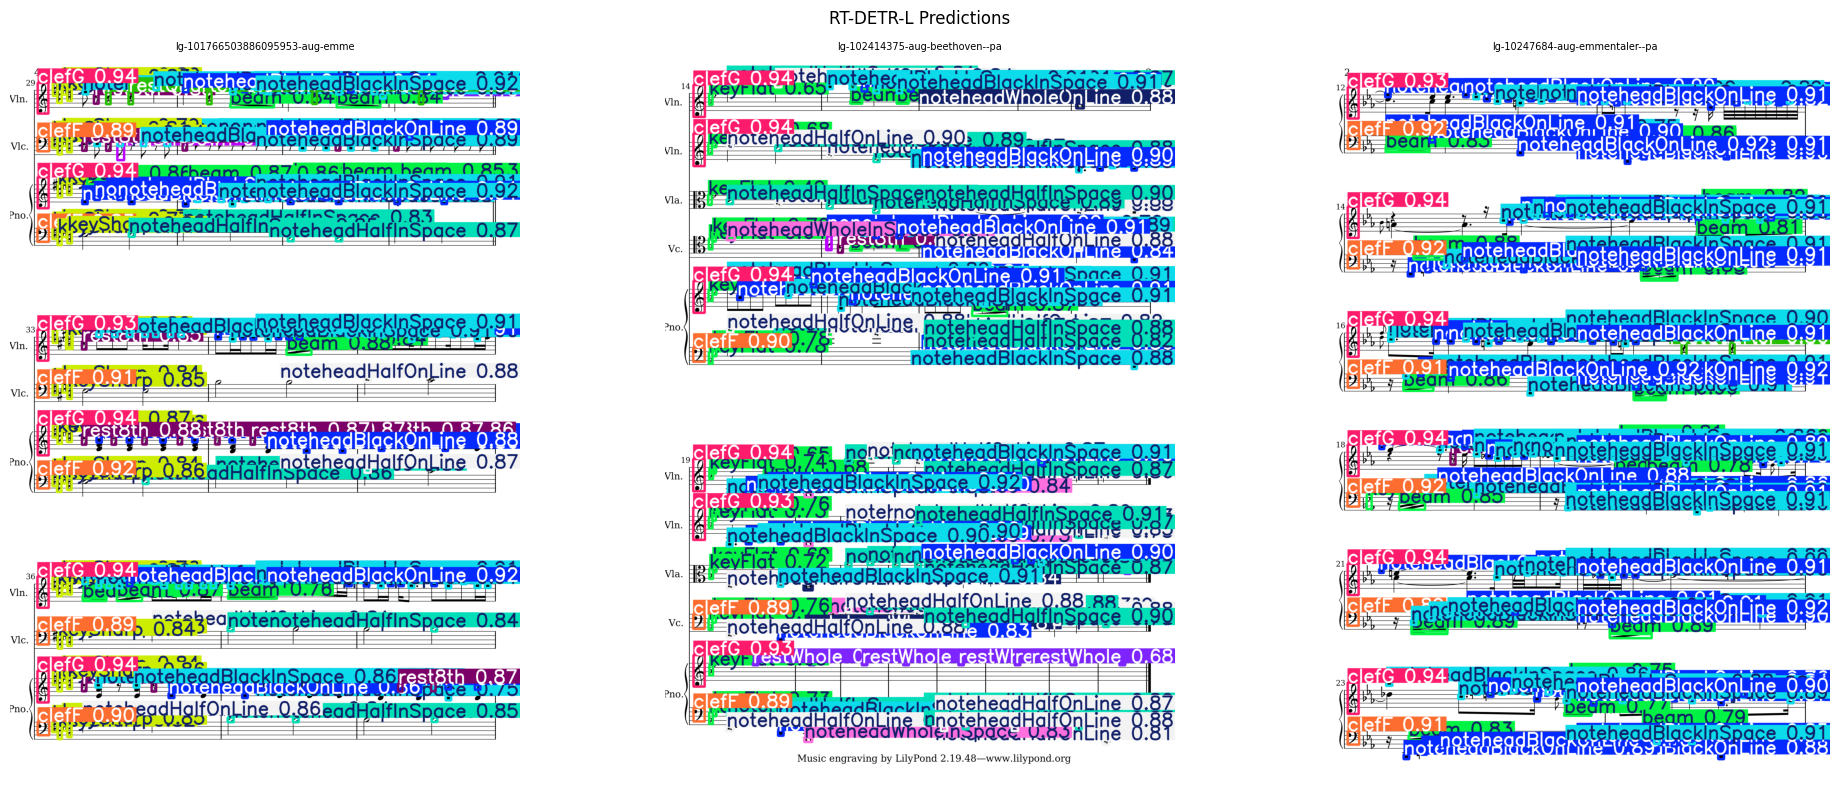

In [3]:
# RT-DETR sample predictions
!pip install ultralytics -q
from ultralytics import RTDETR
import matplotlib.pyplot as plt
import os

model_rtdetr = RTDETR('/content/drive/MyDrive/sheet_music_reader/runs/sheet_music_rtdetr/weights/best.pt')

val_imgs = sorted(os.listdir('/content/yolo_dataset/images/val'))

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, fname in zip(axes, val_imgs[:3]):
    img_path = f'/content/yolo_dataset/images/val/{fname}'
    results = model_rtdetr(img_path, conf=0.3)
    annotated = results[0].plot()
    ax.imshow(annotated[:, :, ::-1])
    ax.set_title(fname[:30], fontsize=7)
    ax.axis('off')
plt.suptitle('RT-DETR-L Predictions', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/rtdetr_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()

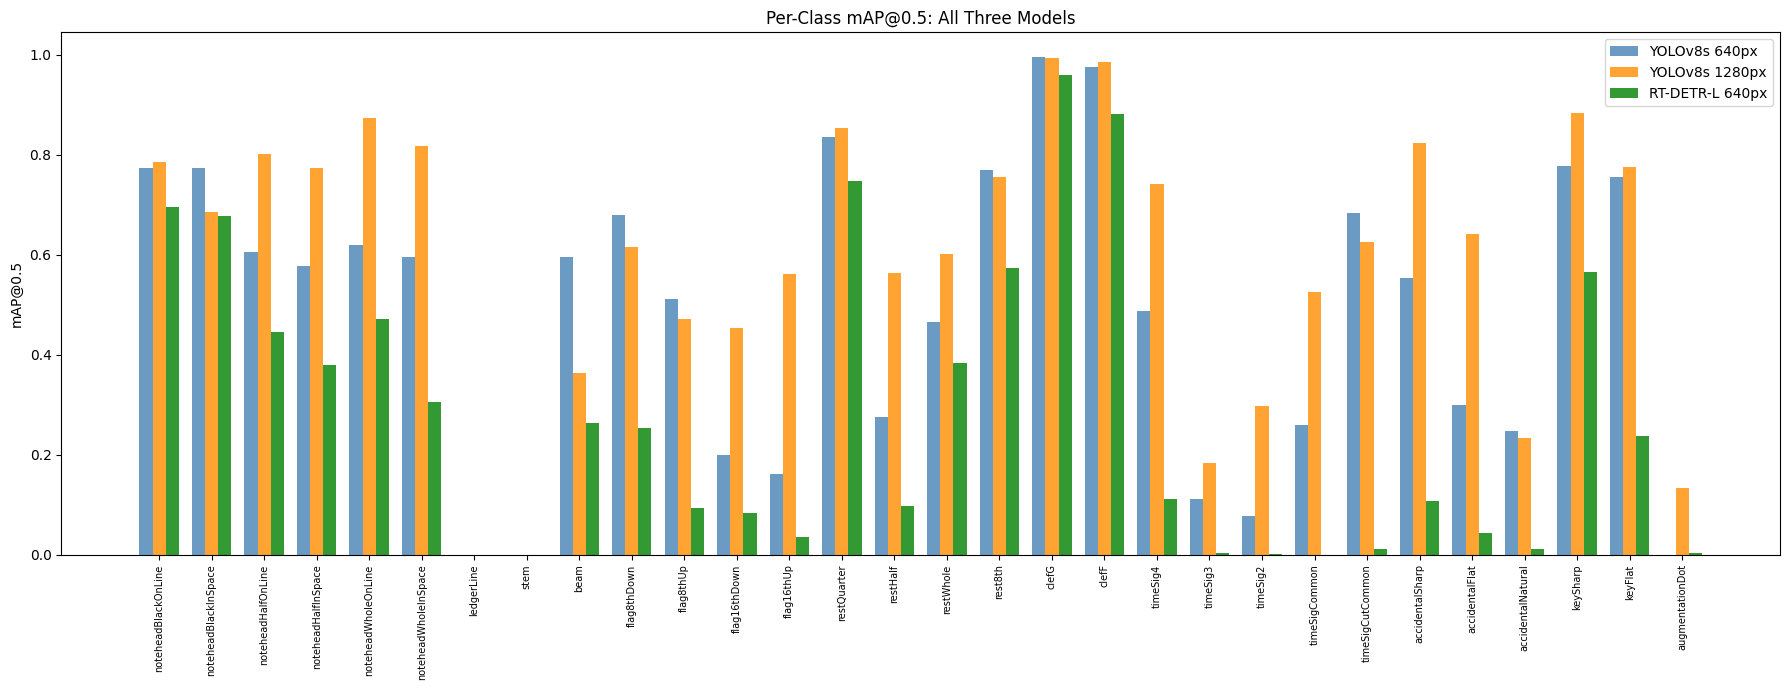

In [5]:
# RT-DETR per-class mAP bar chart
rtdetr_maps = {
    'noteheadBlackOnLine': 0.695, 'noteheadBlackInSpace': 0.678,
    'noteheadHalfOnLine': 0.445, 'noteheadHalfInSpace': 0.379,
    'noteheadWholeOnLine': 0.471, 'noteheadWholeInSpace': 0.305,
    'ledgerLine': 0.000, 'stem': 0.000, 'beam': 0.263,
    'flag8thDown': 0.254, 'flag8thUp': 0.094,
    'flag16thDown': 0.084, 'flag16thUp': 0.035,
    'restQuarter': 0.748, 'restHalf': 0.097, 'restWhole': 0.384,
    'rest8th': 0.574, 'clefG': 0.960, 'clefF': 0.881,
    'timeSig4': 0.111, 'timeSig3': 0.004, 'timeSig2': 0.001,
    'timeSigCommon': 0.000, 'timeSigCutCommon': 0.011,
    'accidentalSharp': 0.107, 'accidentalFlat': 0.044,
    'accidentalNatural': 0.011, 'keySharp': 0.566,
    'keyFlat': 0.238, 'augmentationDot': 0.004
}

baseline_maps = {
    'noteheadBlackOnLine': 0.773, 'noteheadBlackInSpace': 0.773,
    'noteheadHalfOnLine': 0.605, 'noteheadHalfInSpace': 0.577,
    'noteheadWholeOnLine': 0.620, 'noteheadWholeInSpace': 0.596,
    'ledgerLine': 0.000, 'stem': 0.000, 'beam': 0.595,
    'flag8thDown': 0.680, 'flag8thUp': 0.511,
    'flag16thDown': 0.200, 'flag16thUp': 0.162,
    'restQuarter': 0.835, 'restHalf': 0.276, 'restWhole': 0.465,
    'rest8th': 0.769, 'clefG': 0.995, 'clefF': 0.976,
    'timeSig4': 0.487, 'timeSig3': 0.112, 'timeSig2': 0.077,
    'timeSigCommon': 0.260, 'timeSigCutCommon': 0.684,
    'accidentalSharp': 0.553, 'accidentalFlat': 0.299,
    'accidentalNatural': 0.248, 'keySharp': 0.777,
    'keyFlat': 0.755, 'augmentationDot': 0.000
}

high_res_maps = {
    'noteheadBlackOnLine': 0.785, 'noteheadBlackInSpace': 0.685,
    'noteheadHalfOnLine': 0.801, 'noteheadHalfInSpace': 0.774,
    'noteheadWholeOnLine': 0.874, 'noteheadWholeInSpace': 0.818,
    'ledgerLine': 0.000, 'stem': 0.000, 'beam': 0.363,
    'flag8thDown': 0.615, 'flag8thUp': 0.471,
    'flag16thDown': 0.453, 'flag16thUp': 0.562,
    'restQuarter': 0.854, 'restHalf': 0.563, 'restWhole': 0.601,
    'rest8th': 0.755, 'clefG': 0.994, 'clefF': 0.985,
    'timeSig4': 0.742, 'timeSig3': 0.184, 'timeSig2': 0.298,
    'timeSigCommon': 0.525, 'timeSigCutCommon': 0.625,
    'accidentalSharp': 0.824, 'accidentalFlat': 0.642,
    'accidentalNatural': 0.234, 'keySharp': 0.884,
    'keyFlat': 0.775, 'augmentationDot': 0.134
}

# Three-way comparison plot
classes = list(baseline_maps.keys())
x = range(len(classes))
fig, ax = plt.subplots(figsize=(18, 7))
ax.bar([i - 0.25 for i in x], [baseline_maps[c] for c in classes],
       width=0.25, label='YOLOv8s 640px', color='steelblue', alpha=0.8)
ax.bar([i for i in x], [high_res_maps[c] for c in classes],
       width=0.25, label='YOLOv8s 1280px', color='darkorange', alpha=0.8)
ax.bar([i + 0.25 for i in x], [rtdetr_maps[c] for c in classes],
       width=0.25, label='RT-DETR-L 640px', color='green', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(classes, rotation=90, fontsize=7)
ax.set_title('Per-Class mAP@0.5: All Three Models')
ax.set_ylabel('mAP@0.5')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/three_way_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()